# Где IT-специалисту в России выгоднее жить и работать?

## Прикладной проект на реальных данных (регионы РФ)

Цель — найти регионы России, где IT-специалист (роль **Разработчик**) получает **больше денег на руки** после НДФЛ и аренды жилья, то есть максимизирует **располагаемый доход**, а также где ниже стоимость аренды/покупки жилья.

### Важное отличие от США:
В России **НДФЛ — федеральный и единый** для всех регионов (прогрессивная шкала с 2025 года), поэтому «налог по регионам» почти не различается для наёмных работников. Главные региональные факторы — **зарплата** и **стоимость жилья**. Отдельно разберём российскую специфику: **IT-ипотека (~6%)** и **оптимизацию налогов** через форму занятости (НДФЛ / самозанятый / ИП на УСН).

### Источники данных (реальные):
| Показатель | Источник | Период |
|---|---|---|
| Зарплата IT-разработчика по городам | **hh.ru / Habr Career** | 2024 |
| Аренда 1-комн. квартиры | **ЦИАН / Домклик** | 2024 |
| Цена жилья за м² | **Росстат / ЦИАН** | 2024 |
| НДФЛ (прогрессивная шкала) | **ФНС / НК РФ** | 2025 |

> В России нет открытого API уровня Census, поэтому используется **встроенный снимок** опубликованных значений. Как обновить — см. раздел «Источники и оговорки».

### Содержание:
1. Загрузка данных
2. Exploratory Data Analysis (EDA)
3. НДФЛ и доход «на руки» (прогрессивная шкала 2025)
4. Формы занятости: НДФЛ vs самозанятый vs ИП УСН
5. Жильё: аренда vs IT-ипотека
6. Располагаемый доход и доступность жилья
7. Композитный рейтинг регионов
8. Анализ чувствительности
9. Выводы и рекомендации

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 30)

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Загрузка данных

Встроенный снимок реальных опубликованных значений по крупным IT-городам России.

### Столбцы:
- **it_salary** — средняя месячная зарплата разработчика (gross, до налога), ₽
- **rent** — средняя аренда 1-комн. квартиры, ₽/мес
- **price_m2** — цена жилья за м², ₽
- **avg_salary** — средняя зарплата по региону (контекст, Росстат), ₽/мес

In [2]:
# Встроенный снимок (2024): город -> (регион, it_salary, rent, price_m2, avg_salary)
#  it_salary: hh.ru / Habr Career, средняя мес. зарплата разработчика (gross), ₽
#  rent:      ЦИАН, средняя аренда 1-комн. квартиры, ₽/мес
#  price_m2:  Росстат / ЦИАН, цена жилья за м², ₽
#  avg_salary: Росстат, средняя зарплата по региону, ₽/мес
SNAPSHOT = {
  'Москва':            (250000, 60000, 340000, 130000),
  'Санкт-Петербург':   (210000, 38000, 230000, 95000),
  'Новосибирск':       (180000, 28000, 130000, 68000),
  'Екатеринбург':      (175000, 30000, 130000, 70000),
  'Казань':            (175000, 30000, 175000, 65000),
  'Иннополис':         (180000, 32000, 165000, 65000),
  'Нижний Новгород':   (165000, 28000, 140000, 60000),
  'Краснодар':         (160000, 30000, 150000, 58000),
  'Ростов-на-Дону':    (155000, 27000, 120000, 55000),
  'Самара':            (150000, 25000, 110000, 56000),
  'Воронеж':           (150000, 24000, 100000, 52000),
  'Пермь':             (150000, 24000, 110000, 58000),
  'Уфа':               (150000, 25000, 120000, 56000),
  'Красноярск':        (165000, 27000, 120000, 72000),
  'Челябинск':         (150000, 24000, 105000, 58000),
  'Тюмень':            (165000, 30000, 130000, 78000),
  'Томск':             (150000, 25000, 110000, 60000),
  'Калининград':       (155000, 28000, 140000, 55000),
  'Владивосток':       (170000, 35000, 200000, 75000),
  'Волгоград':         (140000, 22000, 95000, 50000),
  'Омск':              (140000, 22000, 100000, 55000),
  'Сочи':              (160000, 50000, 280000, 60000),
}

df = pd.DataFrame(
    [(city, v[0], v[1], v[2], v[3]) for city, v in SNAPSHOT.items()],
    columns=['city', 'it_salary', 'rent', 'price_m2', 'avg_salary']
)
DATA_SOURCE = 'встроенный снимок 2024 (hh.ru / Habr Career / ЦИАН / Росстат)'
print(f'Загружено городов: {len(df)}')
print(f'Источник: {DATA_SOURCE}')
print(df.head())

Загружено городов: 22
Источник: встроенный снимок 2024 (hh.ru / Habr Career / ЦИАН / Росстат)
              city  it_salary   rent  price_m2  avg_salary
0           Москва     250000  60000    340000      130000
1  Санкт-Петербург     210000  38000    230000       95000
2      Новосибирск     180000  28000    130000       68000
3     Екатеринбург     175000  30000    130000       70000
4           Казань     175000  30000    175000       65000


## 2. Exploratory Data Analysis (EDA)

Изучим распределение зарплат IT-специалистов, аренды и цены жилья по городам.

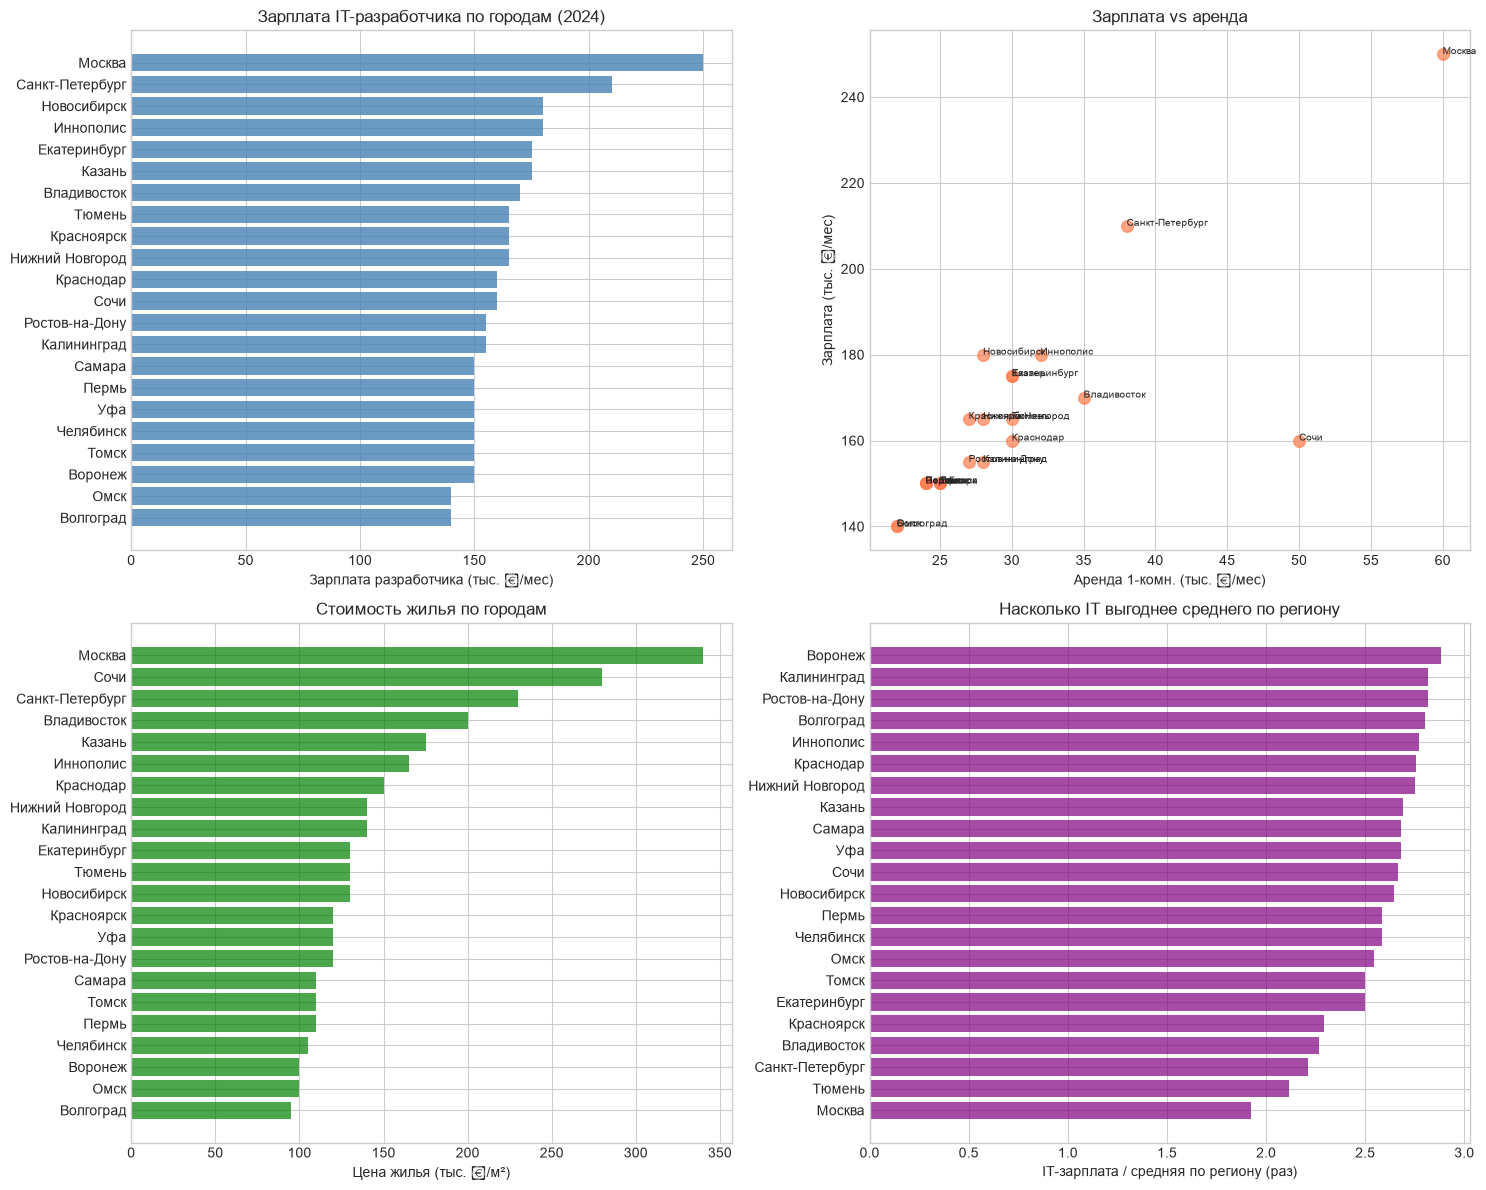

Ключевые статистики:
Медианная зарплата разработчика: 160,000 ₽/мес
Разброс: 140,000 — 250,000 ₽/мес
Медианная аренда: 28,000 ₽/мес
IT-зарплата в среднем выше региональной в 2.6 раза


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Зарплата разработчика по городам
top_wage = df.sort_values('it_salary')
axes[0, 0].barh(top_wage['city'], top_wage['it_salary'] / 1000, color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Зарплата разработчика (тыс. ₽/мес)')
axes[0, 0].set_title('Зарплата IT-разработчика по городам (2024)')

# 2. Зарплата vs аренда
axes[0, 1].scatter(df['rent'] / 1000, df['it_salary'] / 1000, s=70, alpha=0.7, color='coral')
for _, r in df.iterrows():
    axes[0, 1].annotate(r['city'], (r['rent'] / 1000, r['it_salary'] / 1000), fontsize=7)
axes[0, 1].set_xlabel('Аренда 1-комн. (тыс. ₽/мес)')
axes[0, 1].set_ylabel('Зарплата (тыс. ₽/мес)')
axes[0, 1].set_title('Зарплата vs аренда')

# 3. Цена жилья за м²
top_price = df.sort_values('price_m2')
axes[1, 0].barh(top_price['city'], top_price['price_m2'] / 1000, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Цена жилья (тыс. ₽/м²)')
axes[1, 0].set_title('Стоимость жилья по городам')

# 4. IT-зарплата vs средняя по региону (во сколько раз выше)
df['salary_ratio'] = df['it_salary'] / df['avg_salary']
top_ratio = df.sort_values('salary_ratio')
axes[1, 1].barh(top_ratio['city'], top_ratio['salary_ratio'], color='purple', alpha=0.7)
axes[1, 1].set_xlabel('IT-зарплата / средняя по региону (раз)')
axes[1, 1].set_title('Насколько IT выгоднее среднего по региону')

plt.tight_layout()
plt.show()

print('Ключевые статистики:')
print('=' * 60)
print(f'Медианная зарплата разработчика: {df["it_salary"].median():,.0f} ₽/мес')
print(f'Разброс: {df["it_salary"].min():,.0f} — {df["it_salary"].max():,.0f} ₽/мес')
print(f'Медианная аренда: {df["rent"].median():,.0f} ₽/мес')
print(f'IT-зарплата в среднем выше региональной в {df["salary_ratio"].mean():.1f} раза')

## 3. НДФЛ и доход «на руки» (прогрессивная шкала 2025)

С 2025 года в России действует **прогрессивная шкала НДФЛ** (по годовому доходу):

| Годовой доход | Ставка |
|---|---|
| до 2,4 млн ₽ | 13% |
| 2,4–5 млн ₽ | 15% |
| 5–20 млн ₽ | 18% |
| 20–50 млн ₽ | 20% |
| свыше 50 млн ₽ | 22% |

Ставки применяются к части дохода в каждом диапазоне (предельные ставки). Шкала **единая для всех регионов**.

In [4]:
# Прогрессивная шкала НДФЛ 2025 (предельные ставки)
NDFL_BRACKETS = [
    (0,          2_400_000, 0.13),
    (2_400_000,  5_000_000, 0.15),
    (5_000_000, 20_000_000, 0.18),
    (20_000_000,50_000_000, 0.20),
    (50_000_000, np.inf,    0.22),
]

def ndfl(annual_gross):
    tax = 0.0
    for lo, hi, rate in NDFL_BRACKETS:
        if annual_gross > lo:
            tax += (min(annual_gross, hi) - lo) * rate
        else:
            break
    return tax

df['gross_year'] = df['it_salary'] * 12
df['ndfl_year'] = df['gross_year'].apply(ndfl)
df['net_year'] = df['gross_year'] - df['ndfl_year']
df['net_month'] = df['net_year'] / 12
df['eff_ndfl'] = df['ndfl_year'] / df['gross_year']

print('Доход «на руки» после НДФЛ')
print('=' * 70)
show = df.sort_values('net_month', ascending=False)[
    ['city', 'it_salary', 'net_month', 'eff_ndfl']].head(10).copy()
show['it_salary'] = show['it_salary'].map('{:,.0f} ₽'.format)
show['net_month'] = show['net_month'].map('{:,.0f} ₽'.format)
show['eff_ndfl'] = (show['eff_ndfl'] * 100).map('{:.1f}%'.format)
print(show.to_string(index=False))

Доход «на руки» после НДФЛ
           city it_salary net_month eff_ndfl
         Москва 250,000 ₽ 216,500 ₽    13.4%
Санкт-Петербург 210,000 ₽ 182,500 ₽    13.1%
    Новосибирск 180,000 ₽ 156,600 ₽    13.0%
      Иннополис 180,000 ₽ 156,600 ₽    13.0%
   Екатеринбург 175,000 ₽ 152,250 ₽    13.0%
         Казань 175,000 ₽ 152,250 ₽    13.0%
    Владивосток 170,000 ₽ 147,900 ₽    13.0%
Нижний Новгород 165,000 ₽ 143,550 ₽    13.0%
         Тюмень 165,000 ₽ 143,550 ₽    13.0%
     Красноярск 165,000 ₽ 143,550 ₽    13.0%


## 4. Формы занятости: НДФЛ vs самозанятый vs ИП на УСН

В России IT-специалист может снизить налоговую нагрузку через форму занятости. Сравним на примере медианной зарплаты:

- **Наёмный работник:** НДФЛ по прогрессивной шкале (13–15%+).
- **Самозанятый (НПД):** 6% с дохода от юрлиц (лимит 2,4 млн ₽/год).
- **ИП на УСН «доходы»:** 6% (в ряде регионов снижена до 1%) + фиксированные страховые взносы (~53 тыс. ₽ в 2024) + 1% с дохода свыше 300 тыс. ₽.

> Регионы могут устанавливать **пониженную ставку УСН** для IT — это и есть российский аналог «регионального налога». Ставки уточняйте в законе субъекта.

Сравнение форм занятости (доход 1,920,000 ₽/год)
               форма на_руки_год эфф_ставка
      Наёмный (НДФЛ) 1,670,400 ₽      13.0%
Самозанятый (НПД 6%) 1,804,800 ₽       6.0%
           ИП УСН 6% 1,804,800 ₽       6.0%


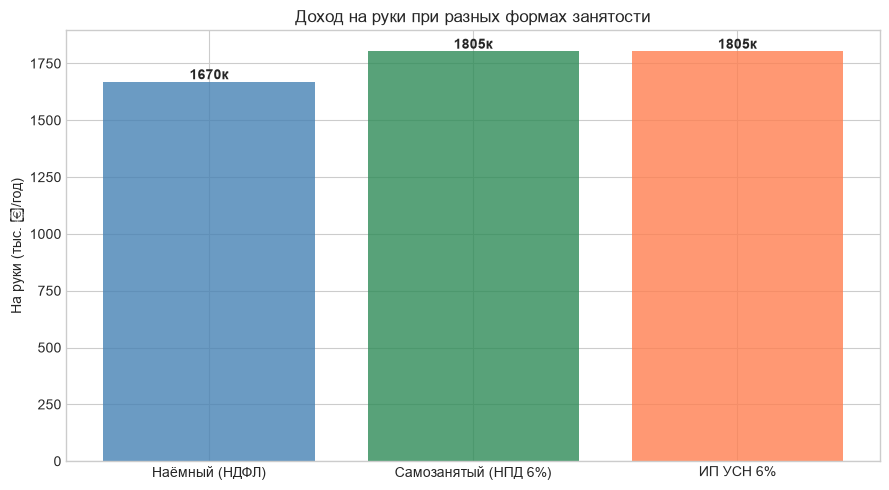


Примечание: у самозанятого лимит дохода 2,4 млн ₽/год; расчёт условный для сравнения ставок.


In [5]:
# Сравнение форм занятости на медианной зарплате
median_gross_year = df['it_salary'].median() * 12

# 1) Наёмный (НДФЛ прогрессивный)
net_employee = median_gross_year - ndfl(median_gross_year)

# 2) Самозанятый 6% (в пределах лимита 2.4 млн; сверх — некорректно, покажем условно)
npd_rate = 0.06
net_selfemployed = median_gross_year * (1 - npd_rate)

# 3) ИП УСН 6% + страховые взносы
FIXED_CONTRIB = 53000        # фикс. страховые взносы 2024
usn_rate = 0.06
usn_tax = median_gross_year * usn_rate
extra_contrib = max(0, (median_gross_year - 300000)) * 0.01  # 1% свыше 300k
# УСН уменьшается на страховые взносы (упрощённо)
net_ip_usn = median_gross_year - max(usn_tax, FIXED_CONTRIB + extra_contrib)

forms = pd.DataFrame({
    'форма': ['Наёмный (НДФЛ)', 'Самозанятый (НПД 6%)', 'ИП УСН 6%'],
    'на_руки_год': [net_employee, net_selfemployed, net_ip_usn],
})
forms['эфф_ставка'] = 1 - forms['на_руки_год'] / median_gross_year

print(f'Сравнение форм занятости (доход {median_gross_year:,.0f} ₽/год)')
print('=' * 60)
fv = forms.copy()
fv['на_руки_год'] = fv['на_руки_год'].map('{:,.0f} ₽'.format)
fv['эфф_ставка'] = (fv['эфф_ставка'] * 100).map('{:.1f}%'.format)
print(fv.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'seagreen', 'coral']
ax.bar(forms['форма'], forms['на_руки_год'] / 1000, color=colors, alpha=0.8)
for i, v in enumerate(forms['на_руки_год']):
    ax.text(i, v / 1000 + 10, f'{v/1000:.0f}к', ha='center', fontweight='bold')
ax.set_ylabel('На руки (тыс. ₽/год)')
ax.set_title('Доход на руки при разных формах занятости')
plt.tight_layout()
plt.show()
print('\nПримечание: у самозанятого лимит дохода 2,4 млн ₽/год; расчёт условный для сравнения ставок.')

## 5. Жильё: аренда vs IT-ипотека

IT-специалисты в России имеют право на льготную **IT-ипотеку** со ставкой ~6% (намного ниже рыночной). Сравним годовые расходы на жильё:
- **Аренда:** `rent * 12`.
- **Покупка (IT-ипотека):** квартира 50 м², первоначальный взнос 20%, ставка 6%, срок 30 лет.

Месячный платёж: $M = P\dfrac{r(1+r)^n}{(1+r)^n-1}$.

In [6]:
# Годовые расходы на жильё
IT_MORTGAGE_RATE = 0.06
DOWN = 0.20
YEARS = 30
AREA = 50  # м²

def annual_mortgage(price_m2):
    home_price = price_m2 * AREA
    P = home_price * (1 - DOWN)
    r = IT_MORTGAGE_RATE / 12
    n = YEARS * 12
    M = P * r * (1 + r) ** n / ((1 + r) ** n - 1)
    return M * 12

df['home_price'] = df['price_m2'] * AREA
df['annual_rent'] = df['rent'] * 12
df['annual_mortgage'] = df['price_m2'].apply(annual_mortgage)

# Располагаемый доход (после НДФЛ и жилья)
df['dispo_rent'] = df['net_year'] - df['annual_rent']
df['dispo_buy'] = df['net_year'] - df['annual_mortgage']

# Доступность
df['rent_burden'] = df['annual_rent'] / df['net_year']
df['price_to_income'] = df['home_price'] / df['gross_year']  # лет зарплаты на квартиру 50м²

print('Аренда vs IT-ипотека (квартира 50 м²) — топ-10 по располагаемому доходу')
print('=' * 80)
cols = ['city', 'net_year', 'annual_rent', 'annual_mortgage', 'dispo_rent', 'price_to_income']
t = df.sort_values('dispo_rent', ascending=False)[cols].head(10).copy()
for c in ['net_year', 'annual_rent', 'annual_mortgage', 'dispo_rent']:
    t[c] = t[c].map('{:,.0f}'.format)
t['price_to_income'] = t['price_to_income'].map('{:.1f} лет'.format)
print(t.to_string(index=False))

Аренда vs IT-ипотека (квартира 50 м²) — топ-10 по располагаемому доходу
           city  net_year annual_rent annual_mortgage dispo_rent price_to_income
         Москва 2,598,000     720,000         978,466  1,878,000         5.7 лет
Санкт-Петербург 2,190,000     456,000         661,904  1,734,000         4.6 лет
    Новосибирск 1,879,200     336,000         374,120  1,543,200         3.0 лет
      Иннополис 1,879,200     384,000         474,844  1,495,200         3.8 лет
   Екатеринбург 1,827,000     360,000         374,120  1,467,000         3.1 лет
         Казань 1,827,000     360,000         503,622  1,467,000         4.2 лет
     Красноярск 1,722,600     324,000         345,341  1,398,600         3.0 лет
Нижний Новгород 1,722,600     336,000         402,898  1,386,600         3.5 лет
         Тюмень 1,722,600     360,000         374,120  1,362,600         3.3 лет
    Владивосток 1,774,800     420,000         575,569  1,354,800         4.9 лет


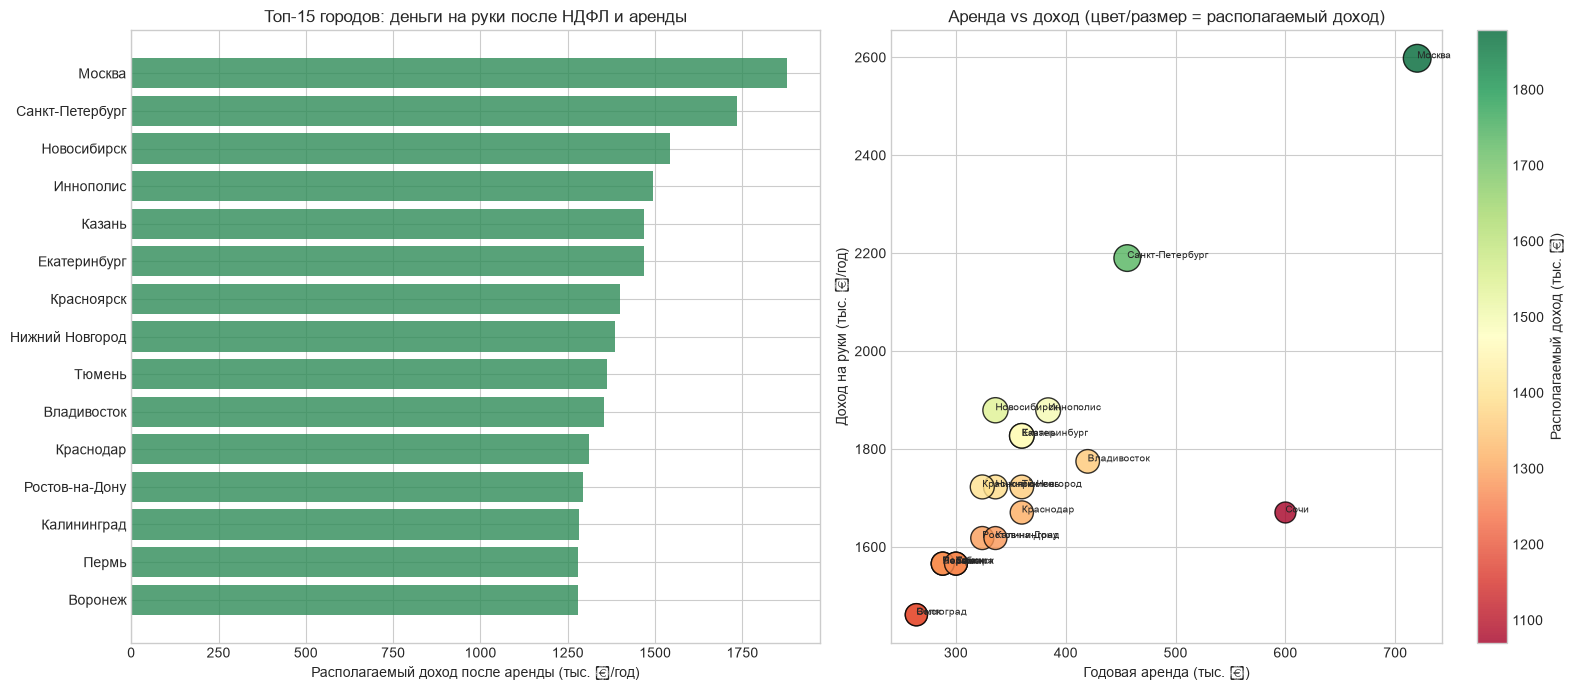

In [7]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_dispo = df.nlargest(15, 'dispo_rent').sort_values('dispo_rent')
axes[0].barh(top_dispo['city'], top_dispo['dispo_rent'] / 1000, color='seagreen', alpha=0.8)
axes[0].set_xlabel('Располагаемый доход после аренды (тыс. ₽/год)')
axes[0].set_title('Топ-15 городов: деньги на руки после НДФЛ и аренды')

sc = axes[1].scatter(df['annual_rent'] / 1000, df['net_year'] / 1000,
                     s=(df['dispo_rent'] / df['dispo_rent'].max() * 400).clip(30),
                     c=df['dispo_rent'] / 1000, cmap='RdYlGn', alpha=0.8, edgecolor='k')
for _, r in df.iterrows():
    axes[1].annotate(r['city'], (r['annual_rent'] / 1000, r['net_year'] / 1000), fontsize=7)
axes[1].set_xlabel('Годовая аренда (тыс. ₽)')
axes[1].set_ylabel('Доход на руки (тыс. ₽/год)')
axes[1].set_title('Аренда vs доход (цвет/размер = располагаемый доход)')
plt.colorbar(sc, ax=axes[1], label='Располагаемый доход (тыс. ₽)')

plt.tight_layout()
plt.show()

## 6–7. Композитный рейтинг регионов

Стандартизируем показатели через **z-оценку** и построим взвешенную сумму:

$$\text{score} = \sum_i w_i \cdot z_i, \qquad z_i = \frac{x_i - \bar{x}_i}{\sigma_i}$$

Для «чем меньше — тем лучше» (аренда, цена жилья) вес отрицательный. НДФЛ единый, поэтому в региональный рейтинг не входит.

In [8]:
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

WEIGHTS = {
    'net_year':        0.40,   # доход на руки — важнее всего
    'dispo_rent':      0.30,   # что остаётся после аренды
    'annual_rent':    -0.15,   # аренда — меньше лучше
    'price_to_income':-0.15,   # доступность покупки жилья — меньше лучше
}

def compute_score(data, weights):
    score = pd.Series(0.0, index=data.index)
    for col, w in weights.items():
        score += w * zscore(data[col])
    return score

df['score'] = compute_score(df, WEIGHTS)
df['rank'] = df['score'].rank(ascending=False).astype(int)
ranking = df.sort_values('score', ascending=False).reset_index(drop=True)

print('ИТОГОВЫЙ РЕЙТИНГ ГОРОДОВ ДЛЯ IT-СПЕЦИАЛИСТА')
print('=' * 85)
view = ranking[['rank', 'city', 'it_salary', 'net_month', 'rent',
                'dispo_rent', 'price_to_income', 'score']].head(15).copy()
view['it_salary'] = view['it_salary'].map('{:,.0f}'.format)
view['net_month'] = view['net_month'].map('{:,.0f}'.format)
view['rent'] = view['rent'].map('{:,.0f}'.format)
view['dispo_rent'] = view['dispo_rent'].map('{:,.0f}'.format)
view['price_to_income'] = view['price_to_income'].map('{:.1f}'.format)
view['score'] = view['score'].map('{:+.2f}'.format)
print(view.to_string(index=False))

ИТОГОВЫЙ РЕЙТИНГ ГОРОДОВ ДЛЯ IT-СПЕЦИАЛИСТА
 rank            city it_salary net_month   rent dispo_rent price_to_income score
    1          Москва   250,000   216,500 60,000  1,878,000             5.7 +1.48
    2 Санкт-Петербург   210,000   182,500 38,000  1,734,000             4.6 +1.11
    3     Новосибирск   180,000   156,600 28,000  1,543,200             3.0 +0.67
    4    Екатеринбург   175,000   152,250 30,000  1,467,000             3.1 +0.42
    5       Иннополис   180,000   156,600 32,000  1,495,200             3.8 +0.41
    6          Казань   175,000   152,250 30,000  1,467,000             4.2 +0.26
    7      Красноярск   165,000   143,550 27,000  1,398,600             3.0 +0.19
    8 Нижний Новгород   165,000   143,550 28,000  1,386,600             3.5 +0.08
    9          Тюмень   165,000   143,550 30,000  1,362,600             3.3 +0.04
   10         Воронеж   150,000   130,500 24,000  1,278,000             2.8 -0.18
   11  Ростов-на-Дону   155,000   134,850 27,000  1,29

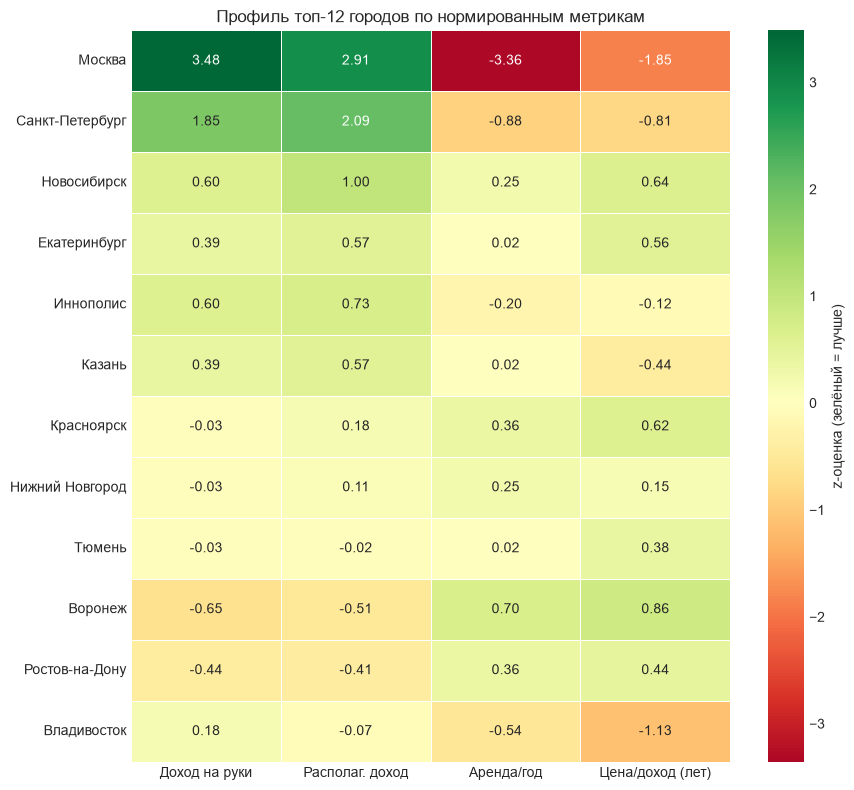

In [9]:
# Тепловая карта нормированных метрик для топ-12
top12 = ranking.head(12).set_index('city')
metrics = ['net_year', 'dispo_rent', 'annual_rent', 'price_to_income']
labels = ['Доход на руки', 'Располаг. доход', 'Аренда/год', 'Цена/доход (лет)']

norm = pd.DataFrame({m: zscore(df.set_index('city')[m]) for m in metrics})
norm = norm.loc[top12.index]
for m in ['annual_rent', 'price_to_income']:
    norm[m] = -norm[m]  # чтобы зелёный = хорошо
norm.columns = labels

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(norm, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'z-оценка (зелёный = лучше)'}, ax=ax)
ax.set_title('Профиль топ-12 городов по нормированным метрикам')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 8. Анализ чувствительности к весам

Сравним три сценария приоритетов: «максимум дохода», «минимум расходов на жильё», «сбалансированный».

Ранги городов в разных сценариях (топ-10 сбалансированного)
           city  Максимум дохода  Минимум жилья  Сбалансированный
         Москва                1             21                 1
Санкт-Петербург                2             12                 2
    Новосибирск                3              1                 3
   Екатеринбург                5              2                 4
      Иннополис                4             13                 5
         Казань                6             17                 6
     Красноярск                7              3                 7
Нижний Новгород                8             11                 8
         Тюмень               10             14                 9
        Воронеж               14              4                10


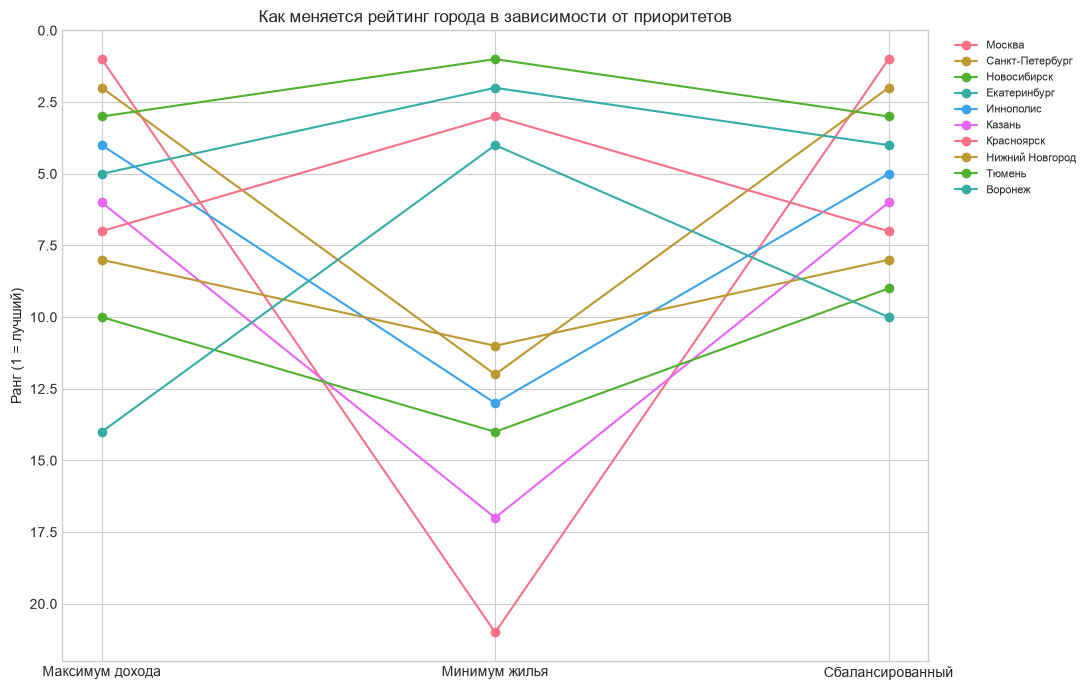

In [10]:
scenarios = {
    'Максимум дохода': {'net_year': 0.60, 'dispo_rent': 0.30,
                        'annual_rent': -0.05, 'price_to_income': -0.05},
    'Минимум жилья':   {'net_year': 0.15, 'dispo_rent': 0.20,
                        'annual_rent': -0.35, 'price_to_income': -0.30},
    'Сбалансированный': WEIGHTS,
}

result = df[['city']].copy()
for name, w in scenarios.items():
    result[name] = compute_score(df, w).rank(ascending=False).astype(int)

top_cities = df.nlargest(10, 'score')['city'].tolist()
comp = result[result['city'].isin(top_cities)].sort_values('Сбалансированный')
print('Ранги городов в разных сценариях (топ-10 сбалансированного)')
print('=' * 70)
print(comp.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
sc_names = list(scenarios.keys())
for _, row in comp.iterrows():
    ranks = [row[s] for s in sc_names]
    ax.plot(sc_names, ranks, marker='o', label=row['city'])
ax.invert_yaxis()
ax.set_ylabel('Ранг (1 = лучший)')
ax.set_title('Как меняется рейтинг города в зависимости от приоритетов')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Выводы и рекомендации

In [11]:
best = ranking.iloc[0]
top5 = ranking.head(5)

print('РЕКОМЕНДАЦИИ ДЛЯ IT-СПЕЦИАЛИСТА В РОССИИ (Разработчик)')
print('=' * 70)
print(f'Источник данных: {DATA_SOURCE}')
print('-' * 70)
print(f'Лучший город по совокупности критериев: {best["city"]}')
print(f'  Зарплата:            {best["it_salary"]:,.0f} ₽/мес')
print(f'  На руки (после НДФЛ): {best["net_month"]:,.0f} ₽/мес')
print(f'  Аренда:              {best["rent"]:,.0f} ₽/мес')
print(f'  Располагаемый доход: {best["dispo_rent"]:,.0f} ₽/год')
print(f'  Квартиру 50 м² окупает за: {best["price_to_income"]:.1f} лет зарплаты')
print('-' * 70)
print('ТОП-5 ГОРОДОВ:')
for _, r in top5.iterrows():
    print(f'  {int(r["rank"])}. {r["city"]:<18} располаг. доход {r["dispo_rent"]:,.0f} ₽/год | '
          f'аренда {r["rent"]:,.0f} ₽/мес')
print('-' * 70)
print('НАБЛЮДЕНИЯ:')
print(f'  - Самая высокая зарплата: {df.loc[df["it_salary"].idxmax(), "city"]} '
      f'({df["it_salary"].max():,.0f} ₽), но и самая дорогая аренда/жильё.')
cheap = df.loc[df["rent"].idxmin(), "city"]
print(f'  - Самая доступная аренда: {cheap} ({df["rent"].min():,.0f} ₽/мес).')
print('  - Города-миллионники с высокой зарплатой и умеренной арендой (Новосибирск,')
print('    Екатеринбург, Казань) часто дают лучший баланс, чем Москва.')
print('  - Налоговую нагрузку можно снизить через самозанятость/ИП УСН (см. раздел 4).')

РЕКОМЕНДАЦИИ ДЛЯ IT-СПЕЦИАЛИСТА В РОССИИ (Разработчик)
Источник данных: встроенный снимок 2024 (hh.ru / Habr Career / ЦИАН / Росстат)
----------------------------------------------------------------------
Лучший город по совокупности критериев: Москва
  Зарплата:            250,000 ₽/мес
  На руки (после НДФЛ): 216,500 ₽/мес
  Аренда:              60,000 ₽/мес
  Располагаемый доход: 1,878,000 ₽/год
  Квартиру 50 м² окупает за: 5.7 лет зарплаты
----------------------------------------------------------------------
ТОП-5 ГОРОДОВ:
  1. Москва             располаг. доход 1,878,000 ₽/год | аренда 60,000 ₽/мес
  2. Санкт-Петербург    располаг. доход 1,734,000 ₽/год | аренда 38,000 ₽/мес
  3. Новосибирск        располаг. доход 1,543,200 ₽/год | аренда 28,000 ₽/мес
  4. Екатеринбург       располаг. доход 1,467,000 ₽/год | аренда 30,000 ₽/мес
  5. Иннополис          располаг. доход 1,495,200 ₽/год | аренда 32,000 ₽/мес
----------------------------------------------------------------------
НАБЛЮ

## Источники и оговорки

**Источники данных:**
- Зарплаты IT: агрегаторы вакансий **hh.ru** и **Habr Career** (медианы по городам, 2024).
- Аренда и цена жилья: **ЦИАН**, **Домклик**, **Росстат** (средние по городам, 2024).
- Средняя зарплата по региону: **Росстат** (ЕМИСС, [fedstat.ru](https://www.fedstat.ru)).
- НДФЛ: **НК РФ**, прогрессивная шкала с 01.01.2025; страховые взносы ИП — **ФНС** 2024.
- IT-ипотека: госпрограмма, ставка до 6% (условия менялись — проверяйте актуальные).

**Оговорки (важно для корректной интерпретации):**
1. В отличие от США, в России нет открытого API уровня Census — данные заданы встроенным снимком опубликованных значений и требуют ручного обновления.
2. Зарплаты сильно зависят от грейда (junior/middle/senior) и стека; здесь — усреднённые.
3. НДФЛ единый для всех регионов; реальная нагрузка зависит от вычетов и формы занятости.
4. Аренда/цена жилья — средние по городу и скрывают разницу между районами.
5. Не учтены: коммунальные платежи, транспорт, налог с продаж отсутствует (в РФ — НДС в цене).
6. Условия IT-ипотеки и лимиты самозанятости периодически меняются законодательно.

## Упражнения

### Упражнение 1: Грейды
1. Добавьте столбцы зарплат для junior / middle / senior
2. Как меняется рейтинг городов для senior?

### Упражнение 2: Полные расходы
1. Добавьте коммунальные платежи и транспорт по городам
2. Пересчитайте располагаемый доход

### Упражнение 3: Аренда vs ипотека
1. Постройте рейтинг по `dispo_buy` (IT-ипотека) вместо аренды
2. При какой ставке ипотеки покупка выгоднее аренды в вашем городе?

### Упражнение 4: Форма занятости
1. Постройте график «доход на руки vs форма занятости» для разных уровней дохода
2. При каком доходе выгоднее ИП УСН, а при каком — самозанятость?

### Упражнение 5: Свои приоритеты
1. Задайте свои веса в `WEIGHTS` (например, доступность покупки жилья важнее всего)
2. Как меняется ваш личный топ-5?

---

**Решения** можно найти в ноутбуке `solutions/19_Solutions.ipynb`